Fruit Image Classification using CNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install kaggle -q

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chaitanyakrishna018","key":"396935d089b1d8aeacfbf607549ce38b"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API ready!")

Kaggle API ready!


In [5]:
!kaggle datasets download -d moltean/fruits
!unzip -q fruits.zip -d /content/fruits
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 5.99G/5.99G [01:02<00:00, 102MB/s]

Dataset ready!


In [6]:
!unzip -q -o fruits.zip -d /content/fruits

In [32]:
import os

print(os.listdir('/content/fruits/fruits-360_100x100'))
print(os.listdir('/content/fruits/fruits-360_100x100/fruits-360/'))

['fruits-360']
['Test', 'Training', 'LICENSE', 'README.md']


In [34]:
import os

original_test = '/content/fruits/fruits-360_100x100/fruits-360/Test'

# Search for blackberry folders
all_test = os.listdir(original_test)
blackberry = [f for f in all_test if 'Blackberry' in f or 'blackberry' in f]
print("Blackberry folders in test:", blackberry)

Blackberry folders in test: ['Blackberry 1', 'Blackberry 4', 'Blackberry 3', 'Blackberry 2', 'Blackberry 5']


In [35]:
train_fruits = set(os.listdir('/content/small_train'))
test_fruits = set(os.listdir('/content/small_test'))

print("Missing in test:", train_fruits - test_fruits)
print("Missing in train:", test_fruits - train_fruits)

Missing in test: {'BlackBerry 4'}
Missing in train: set()


In [42]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------- Original paths ----------
original_train = '/content/fruits/fruits-360_100x100/fruits-360/Training'
original_test  = '/content/fruits/fruits-360_100x100/fruits-360/Test'


blackberry_path = '/content/small_train/BlackBerry 4'
if os.path.exists(blackberry_path):
    shutil.rmtree(blackberry_path)

#--------- pick fruits common in both sets
train_list     = set(os.listdir(original_train))
test_list      = set(os.listdir(original_test))
common_fruits  = list(train_list & test_list)[:15]  # only 10 fruits
print("✅ Selected fruits:", common_fruits)

# Create new folders
os.makedirs('/content/small_train', exist_ok=True)
os.makedirs('/content/small_test', exist_ok=True)

# Copy only 10 fruits
for fruit in selected_fruits:
    # Copy to small_train
    shutil.copytree(
        os.path.join(original_train, fruit),
        os.path.join('/content/small_train', fruit),
        dirs_exist_ok=True
    )
    # Check if fruit exists in original_test before copying
    test_fruit_path = os.path.join(original_test, fruit)
    if os.path.exists(test_fruit_path):
        shutil.copytree(
            test_fruit_path,
            os.path.join('/content/small_test', fruit),
            dirs_exist_ok=True
        )
    else:
        print(f"Warning: Skipping '{fruit}' for test data as it does not exist in {original_test}")

# Load small dataset
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/small_train',
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    '/content/small_test',
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)

# print("Train classes:", len(train_data.class_indices))
# print("Test classes:", len(test_data.class_indices))
# print("Train fruits:", list(train_data.class_indices.keys()))
# print("Test fruits:", list(test_data.class_indices.keys()))
print("✅ Classes:", len(train_data.class_indices))
print("✅ Training images:", train_data.samples)
print("✅ Test images:", test_data.samples)

✅ Selected fruits: ['Orange 1', 'Hazelnut 1', 'Pepper Red 1', 'Peanut shell 1x 1', 'Peach Flat 1', 'Cantaloupe 3', 'Apple 6', 'Kohlrabi 1', 'Apple 22', 'Cherry Rainier 2', 'orange 4', 'Redcurrant 1', 'Cauliflower 1', 'Cherry 2', 'Pepper 1']
Found 9710 images belonging to 19 classes.
Found 3226 images belonging to 19 classes.
✅ Classes: 19
✅ Training images: 9710
✅ Test images: 3226


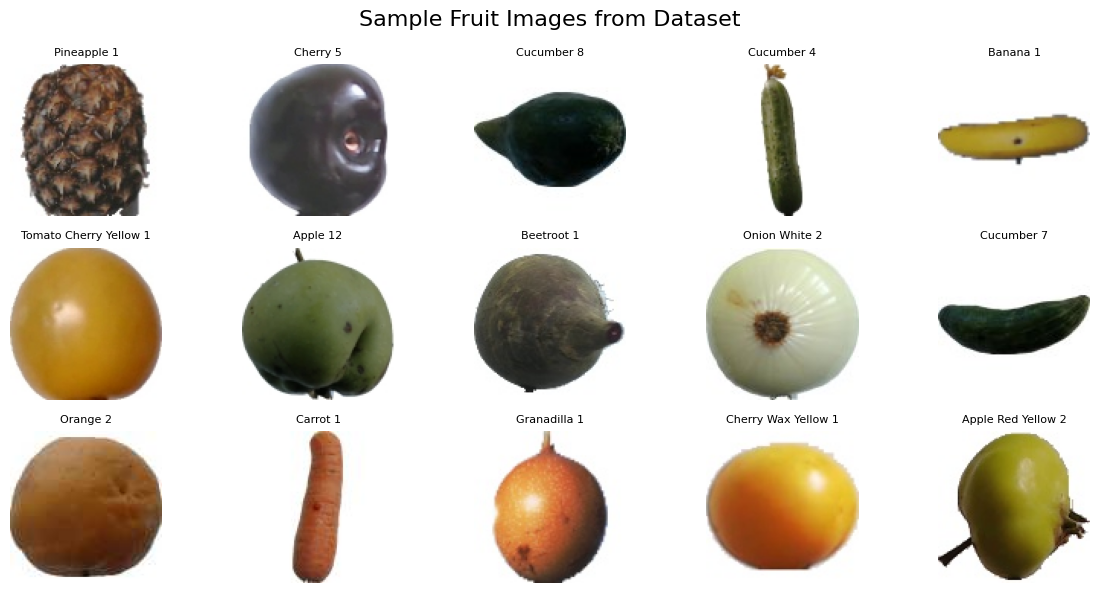

In [43]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os

train_dir = '/content/fruits/fruits-360_100x100/fruits-360/Training'
fruits = os.listdir(train_dir)[:20]

fig, axes = plt.subplots(3, 5, figsize=(12, 6))

for ax, fruit in zip(axes.flatten(), fruits):
    fruit_path = os.path.join(train_dir, fruit)

    img_file = random.choice(os.listdir(fruit_path))
    img = load_img(os.path.join(fruit_path, img_file),
                   target_size=(100,100))

    ax.imshow(img)
    ax.set_title(fruit, fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Fruit Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [44]:
# CNN Model (means reconize the fruit by looking at pictures)

from tensorflow.keras.models import Sequential # stack layers one by one
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
num_classes = len(train_data.class_indices) # Total number of fruits

num_classes = len(train_data.class_indices)
print("Number of classes:", num_classes)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2,2), # shrink image by half(keeps only important info)
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),#Converts 2D image → 1D list
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

Number of classes: 19


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,375,187 (12.88 MB)

 Trainable params: 3,375,187 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [46]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data,
    verbose = 1
)

Epoch 1/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 237s 773ms/step - accuracy: 0.8628 - loss: 0.4430 - val_accuracy: 0.9547 - val_loss: 0.1606
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 224s 738ms/step - accuracy: 0.9859 - loss: 0.0422 - val_accuracy: 0.9802 - val_loss: 0.0643
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 263s 740ms/step - accuracy: 0.9880 - loss: 0.0406 - val_accuracy: 0.9805 - val_loss: 0.0778
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 225s 739ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.9820 - val_loss: 0.0466
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 261s 735ms/step - accuracy: 0.9917 - loss: 0.0252 - val_accuracy: 0.9823 - val_loss: 0.0485
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 262s 735ms/step - accuracy: 0.9903 - loss: 0.0337 - val_accuracy: 0.9854 - val_loss: 0.0758
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 221s 727ms/step - accuracy: 0.9955 - loss: 0.0138 - val_accuracy: 0.9919 - val_loss: 0.0201
Epoch 8/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 263s 731ms/step - accuracy: 0.9974 -

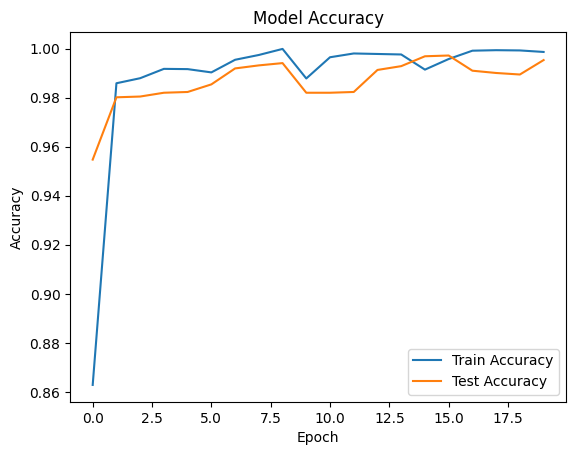

In [47]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Confusion Matrix

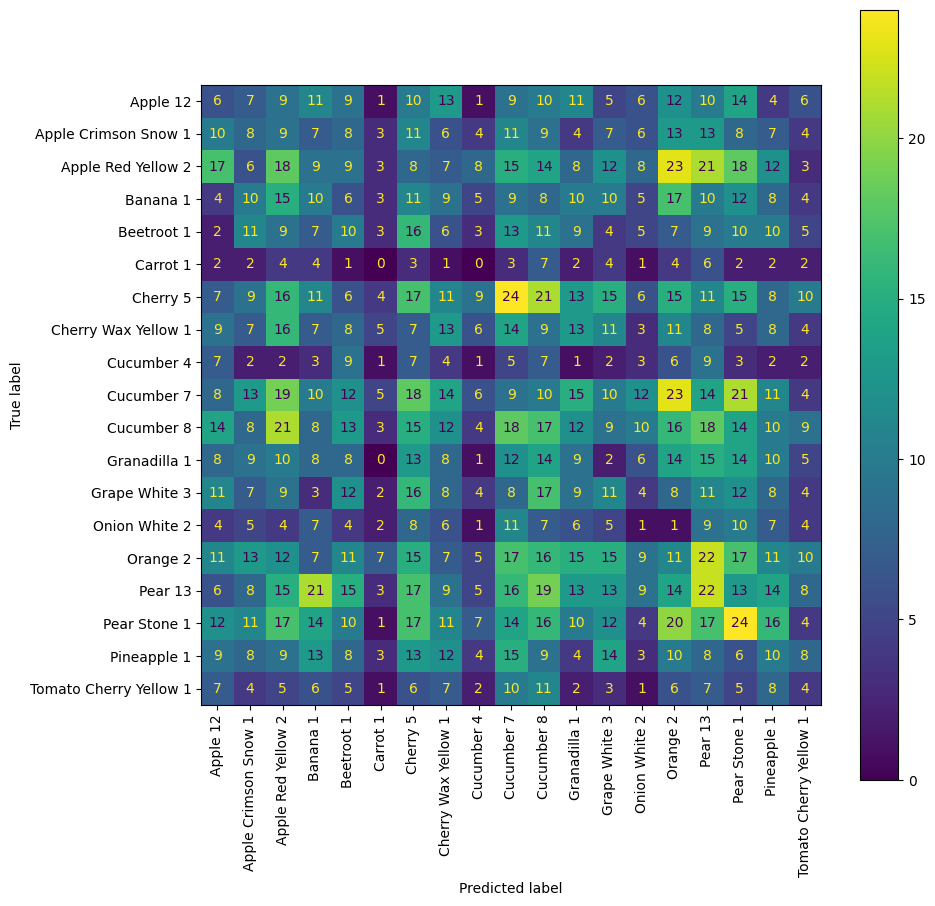

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(test_data.class_indices.keys())
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, xticks_rotation=90)
plt.show()

Evaluating the model

In [48]:
loss, accuracy = model.evaluate(test_data)
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")

101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 223ms/step - accuracy: 0.9954 - loss: 0.0103
✅ Test Accuracy: 99.54%


Model Saving

In [49]:
model.save('/content/drive/MyDrive/fruit_model.keras')
print("✅ Model saved!")

✅ Model saved!


Predicting new fruit

In [56]:
import os # Added import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

class_names = list(train_data.class_indices.keys())

test_dir = '/content/small_test'
test_fruit_class = class_names[15] # Changed index from 20 to 0 (e.g., 'Apple Braeburn')

sample_class_path = os.path.join(test_dir, test_fruit_class)

if os.path.exists(sample_class_path) and os.listdir(sample_class_path):
    sample_image_filename = os.listdir(sample_class_path)[0]
    img_to_predict_path = os.path.join(sample_class_path, sample_image_filename)
else:
    raise FileNotFoundError(f"Could not find any images in {sample_class_path} or directory does not exist.")


img = load_img(img_to_predict_path, target_size=(100,100)) # Use the dynamically generated path
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_fruit = class_names[np.argmax(prediction)]

print(f"Predicted Fruit: {predicted_fruit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Fruit: Pear 13


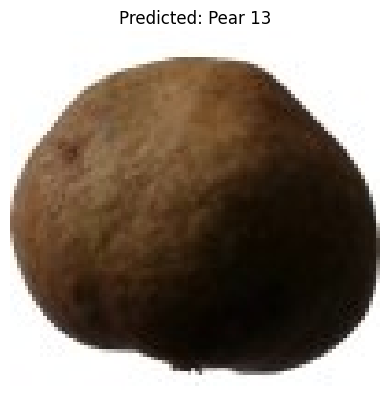

In [57]:
import matplotlib.pyplot as plt

# Display the image
plt.imshow(img)
plt.title(f"Predicted: {predicted_fruit}")
plt.axis('off')
plt.show()
